In [30]:
import nifty.re as jft
from jax import random
from jax import numpy as jnp
import numpy as np
import jax

import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100

jax.config.update("jax_enable_x64", True)

shape = 200
distances = 5
seed = 50
key = random.PRNGKey(seed)

In [31]:
def fieldmaker(shape, distances, prefix, **args):
    cfm = jft.CorrelatedFieldMaker(prefix=f"{prefix}")
    cfm.set_amplitude_total_offset(
        offset_mean=args["offset_mean"], offset_std=args["offset_std"]
    )
    args.pop("offset_mean")
    args.pop("offset_std")
    cfm.add_fluctuations(
        shape=shape,
        distances=distances,
        **args,
    )
    cf_model = cfm.finalize()

    return cf_model, cfm.power_spectrum

In [32]:
cf_kwargs = {
    "offset_mean": 21.0,
    "offset_std": (1.0, 1e-3),
    "fluctuations": (2.0, 1.0),
    "loglogavgslope": (-2.0, 0.3),
    "flexibility": (2.0, 1.0),
    "asperity": (1.0, 0.5),
    "prefix": "",
}

In [33]:
model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)

In [34]:
key, *subkeys = random.split(key, 5)
xi_samples = [jft.random_like(sk, model.domain) for sk in subkeys]

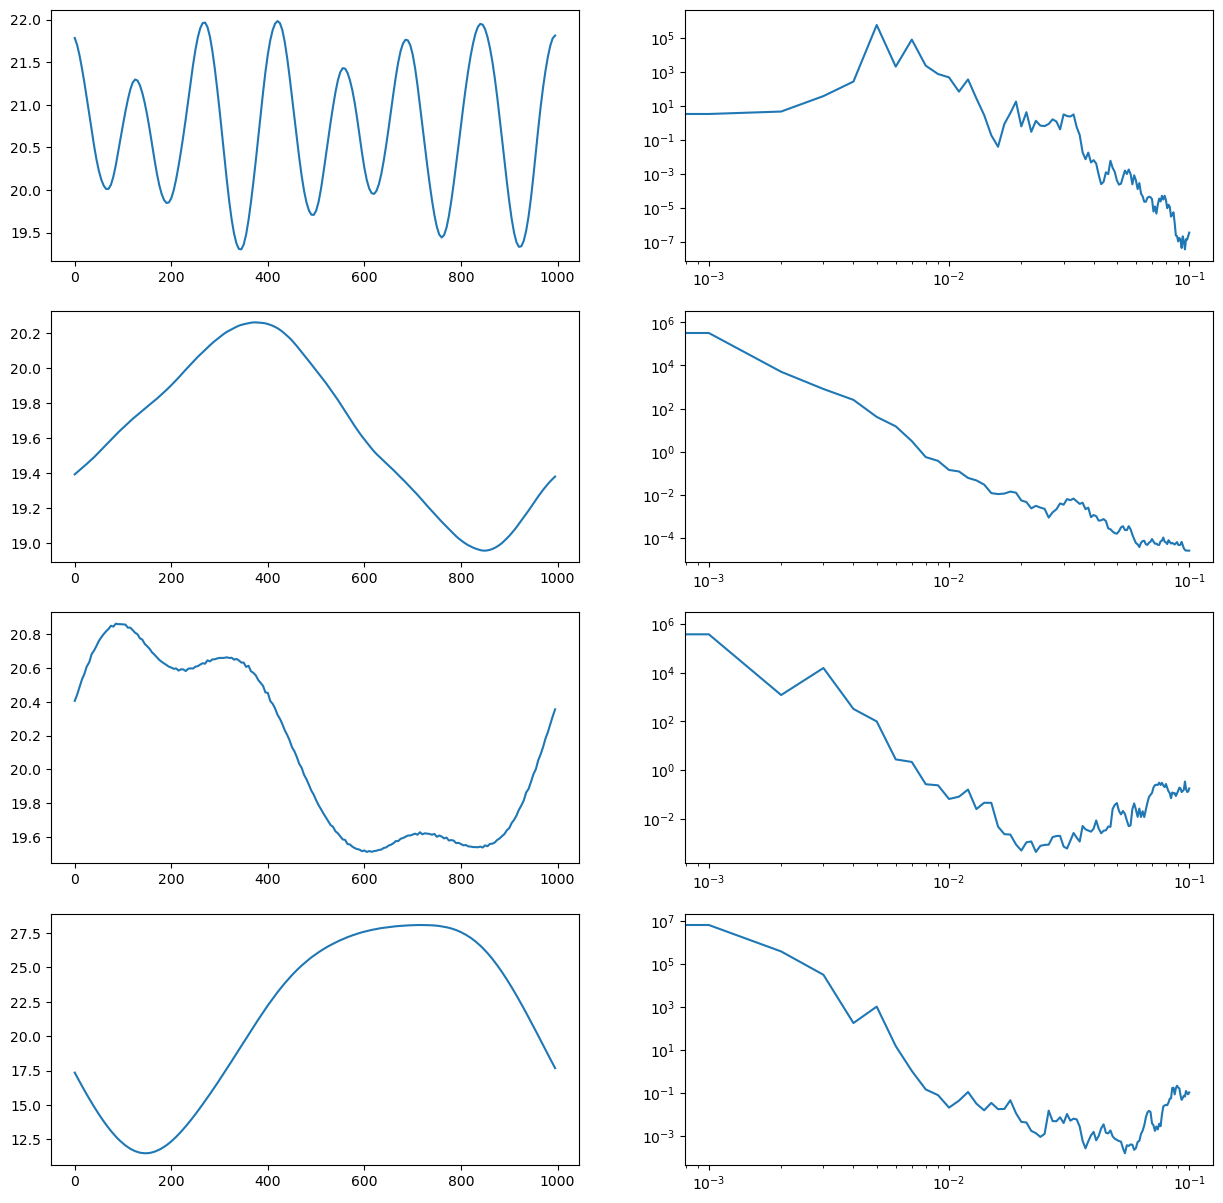

In [35]:
x_vec = model.target_grids[0].distances[0] * np.arange(
    shape
)  # sampling points of Gaussian process
k_vec = model.target_grids[
    0
].harmonic_grid.mode_lengths  # fourier modes of amplitude spectrum

fig, axes = plt.subplots(len(xi_samples), 2, figsize=(15, 15))
for i, xi in enumerate(xi_samples):
    axes[i, 0].plot(x_vec, model(xi))
    axes[i, 1].loglog(k_vec, ps(xi))
plt.show()

In [42]:
t = np.load("data/time_200.npy")
true = np.load("data/true_trace_200.npy")

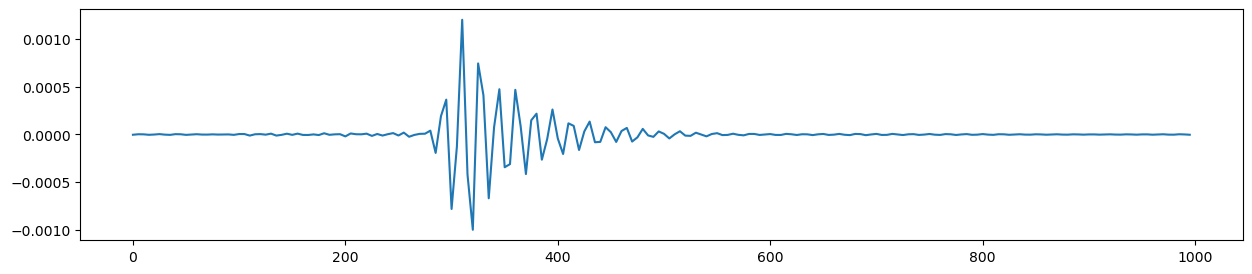

In [45]:
plt.figure(figsize=(15, 3))
plt.plot(t, true)
plt.show()

In [60]:
shape = 200
distances = 5e-9

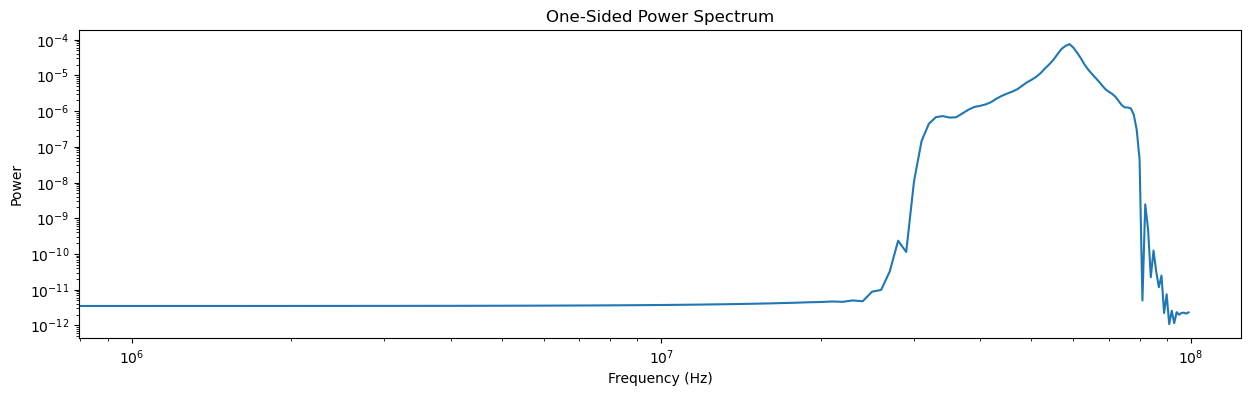

In [59]:
# 1. Generate a mock time-series signal
time_step = 5e-9
t = np.arange(0, 200)*time_step

# 2. Compute the Fast Fourier Transform (FFT)
fft_result = np.fft.fft(true)

# 3. Calculate the power spectrum (squared magnitude)
power_spectrum = np.abs(fft_result) ** 2

# 4. Generate the corresponding frequencies
frequencies = np.fft.fftfreq(true.size, d=time_step)

# 5. Extract the positive (one-sided) frequencies for real-valued inputs
positive_frequencies_mask = frequencies >= 0
freqs_side = frequencies[positive_frequencies_mask]
power_side = power_spectrum[positive_frequencies_mask]

# 6. Plot the power spectrum
plt.figure(figsize=(15, 4))
plt.plot(freqs_side, power_side)
plt.title("One-Sided Power Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.loglog()
plt.show()

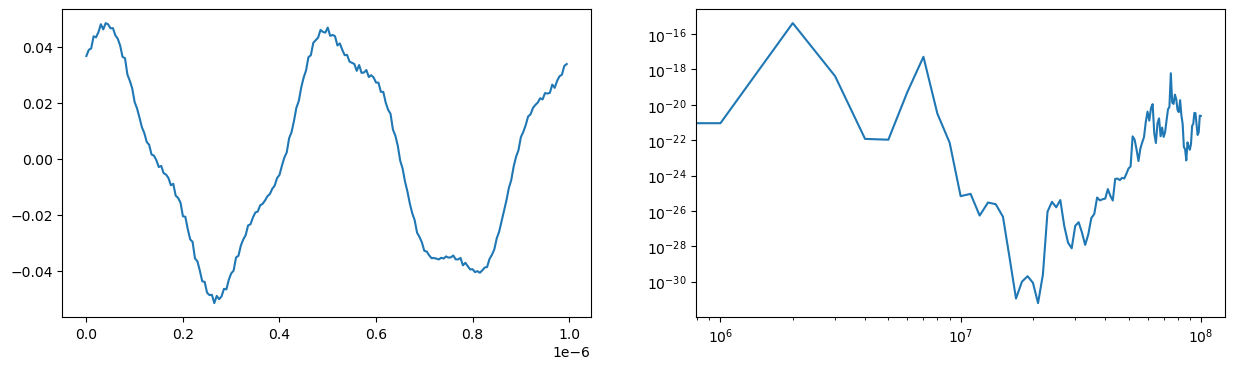

In [67]:
cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-7),
    "fluctuations": (2.9e-2, 1e-8),
    "loglogavgslope": (-2., 1.),
    "flexibility": (10.0, 1.0),
    "asperity": (1.0, 0.5),
    "prefix": "",
}

# cf_kwargs = {
#     "offset_mean": 0,
#     "offset_std": (1e-3, 5e-4),
#     "fluctuations": (5e-4, 2e-4),
#     "loglogavgslope":(-3.0, 1.0),
#     "flexibility": (0.5, 0.3),
#     "asperity": (0.1, 0.05),
#     "prefix": "",
# }

model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)

key, *subkeys = random.split(key, 2)
xi_samples = [jft.random_like(sk, model.domain) for sk in subkeys]

x_vec = model.target_grids[0].distances[0] * np.arange(
    shape
)  # sampling points of Gaussian process
k_vec = model.target_grids[
    0
].harmonic_grid.mode_lengths  # fourier modes of amplitude spectrum

fig, axes = plt.subplots(len(xi_samples), 2, figsize=(15, 4))
for i, xi in enumerate(xi_samples):
    axes[0].plot(x_vec, model(xi))
    axes[1].loglog(k_vec, ps(xi))
plt.show()

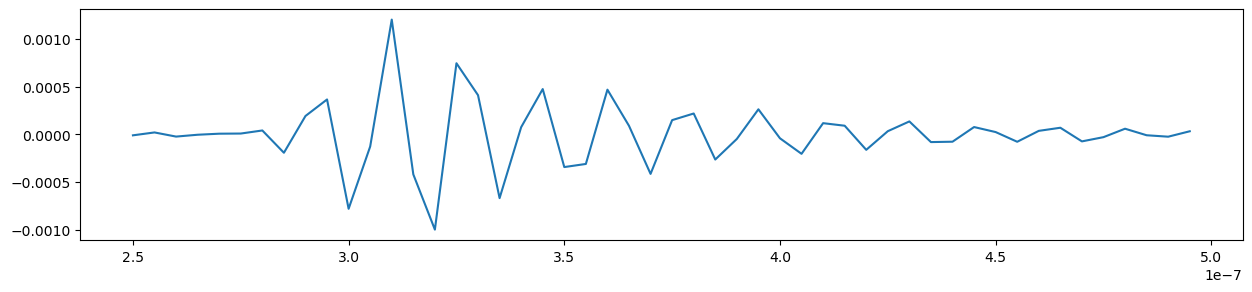

In [66]:
plt.figure(figsize=(15, 3))
plt.plot(t[50:100], true[50:100])
plt.show()

In [78]:
shape = 50
distances = 5e-9

In [72]:
def func(m, s, s_s, f, f_s, l, l_s, x, x_s, a, a_s):
    cf_kwargs = {
    "offset_mean": m,
    "offset_std": (s, s_s),
    "fluctuations": (f, f_s),
    "loglogavgslope": (l, l_s),
    "flexibility": (x, x_s),
    "asperity": (a, a_s),
    "prefix": "",
}
    
    model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)

    seed = 50
    key = random.PRNGKey(seed)
    key, *subkeys = random.split(key, 2)
    xi_samples = [jft.random_like(sk, model.domain) for sk in subkeys]

    return model(xi_samples[0])

In [80]:
from scipy.optimize import least_squares

In [ ]:
def residual(params):
    F = func(*params)
    return (F-true[50:100])*1e5

In [88]:
lower=[0, 0, 0, 0, 0, -10, 0, 0, 0, 0, 0]
upper=[1e-3, 1e-3, 1e-3, 1, 1, 10, 5, np.inf, np.inf, np.inf, np.inf]
p0 = (0, 1.71e-4, 1e-7, 2.9e-2, 1e-8, -2., 1., 10.0, 1.0, 1.0, 0.5,)

res = least_squares(residual, p0, bounds=(lower, upper))

In [89]:
res

     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [ 1.353e-05 -2.497e-05 ...  3.274e-05 -2.349e-05]
           x: [ 6.557e-05  2.167e-04  2.689e-05  5.336e-03  4.368e-01
               -9.892e+00  1.741e-04  6.878e+01  3.426e+01  7.149e-07
                1.020e+01]
        cost: 2.918824579625125e-06
         jac: [[ 1.000e+00 -2.951e-01 ... -2.634e-08  0.000e+00]
               [ 1.000e+00 -2.951e-01 ... -6.453e-08  0.000e+00]
               ...
               [ 1.000e+00 -2.951e-01 ...  4.417e-08  0.000e+00]
               [ 1.000e+00 -2.951e-01 ...  1.860e-08  0.000e+00]]
        grad: [-3.223e-08  9.511e-09  1.805e-09  8.192e-07 -5.668e-09
                4.417e-11  3.784e-11  4.308e-12  5.224e-12  9.876e-12
                0.000e+00]
  optimality: 4.371226766485637e-09
 active_mask: [0 0 0 0 0 0 0 0 0 0 0]
        nfev: 12
        njev: 12